## MaxPooling layer

In [ ]:
import torch
import torch.nn as nn

input_data = torch.tensor([[1.0, 1.0, 2.0, 4.0], [5.0, 6.0, 7.0, 8.0], [3.0, 2.0, 1.0, 0.0], [1.0, 2.0, 3.0, 4.0]], dtype=torch.float32)


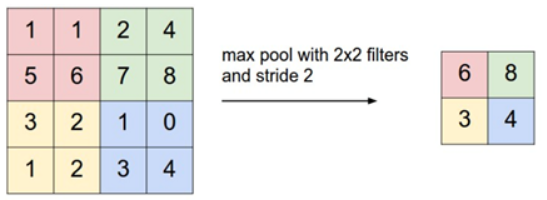

**Slice tensor**

In [ ]:
input_data[:2, :2] # Is equal to input_data[0:2, 0:2]

**MaxPooling - A) single position**

In [ ]:
result = torch.max(input_data[:2, :2])
print(f"Result: {result}")

**MaxPooling - B) All positions**

In [ ]:
result = torch.zeros((2, 2), dtype=torch.float32)

stride = 2
size = 2
w, h = input_data.shape

for i in range(0, int(w / stride)):
    for j in range(0, int(h / stride)):
        res = input_data[i*stride:i*stride + size, j*stride:j*stride + size]
        result[i, j] = torch.max(res)
        print(f"Assigning value {torch.max(res)} to indices [{i}, {j}]")

print(f"Output feature map:\n {result}")


**Custom maxpooling layer**

In [ ]:
class MyMaxPool2d(nn.Module):
    def __init__(self, kernel_size=2, stride=2):
        super().__init__()

        self.kernel = nn.Parameter(torch.randn(kernel_size, dtype=torch.float32) * 0.01)
        self.size = kernel_size
        self.stride = stride

    def forward(self, x):
        result = torch.zeros((2, 2), dtype=torch.float32)
        w, h = x.shape

        for i in range(0, int(w / self.stride)):
            for j in range(0, int(h / self.stride)):
                res = x[i*self.stride:i*self.stride + self.size, j*self.stride:j*self.stride + self.size]
                result[i, j] = torch.max(res)

        return result


print(f"Input data:\n {input_data}")

mp = MyMaxPool2d()
out = mp(input_data)
print(f"Result:\n {out}")
